## Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report

c:\Users\USER\OneDrive\Desktop\irrigation-prediction\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading

In [2]:
irrigations_train = pd.read_csv('data/train.csv')
irrigations_test = pd.read_csv('data/test.csv')

## Inpecting the Data

In [3]:
# no missing values
print("train missing values: \n", irrigations_train.isnull().sum())
print("test missing values: \n", irrigations_test.isnull().sum())

irrigations_train.info()
irrigations_test.describe()

train missing values: 
 id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64
test missing values: 
 id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type   

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


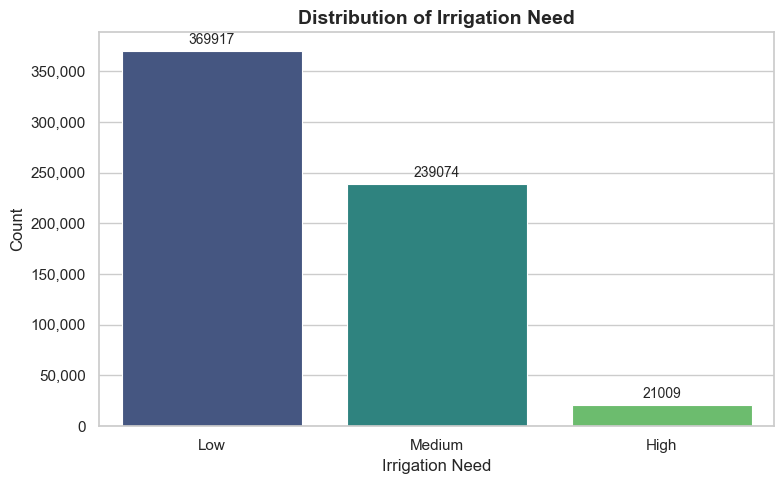

In [4]:
# Distribution of Irrigation Need (categorical — bar counts, not histogram + KDE)
sns.set_theme(style="whitegrid", context="notebook")
preferred = ["Low", "Medium", "High"]
order = [c for c in preferred if c in set(irrigations_train["Irrigation_Need"])]
if not order:
    order = irrigations_train["Irrigation_Need"].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=irrigations_train,
    x="Irrigation_Need",
    order=order,
    hue="Irrigation_Need",
    hue_order=order,
    palette="viridis",
    legend=False,
    ax=ax,
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title("Distribution of Irrigation Need", fontsize=14, fontweight="semibold")
ax.set_xlabel("Irrigation Need")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3, fontsize=10)
plt.tight_layout()
plt.show()

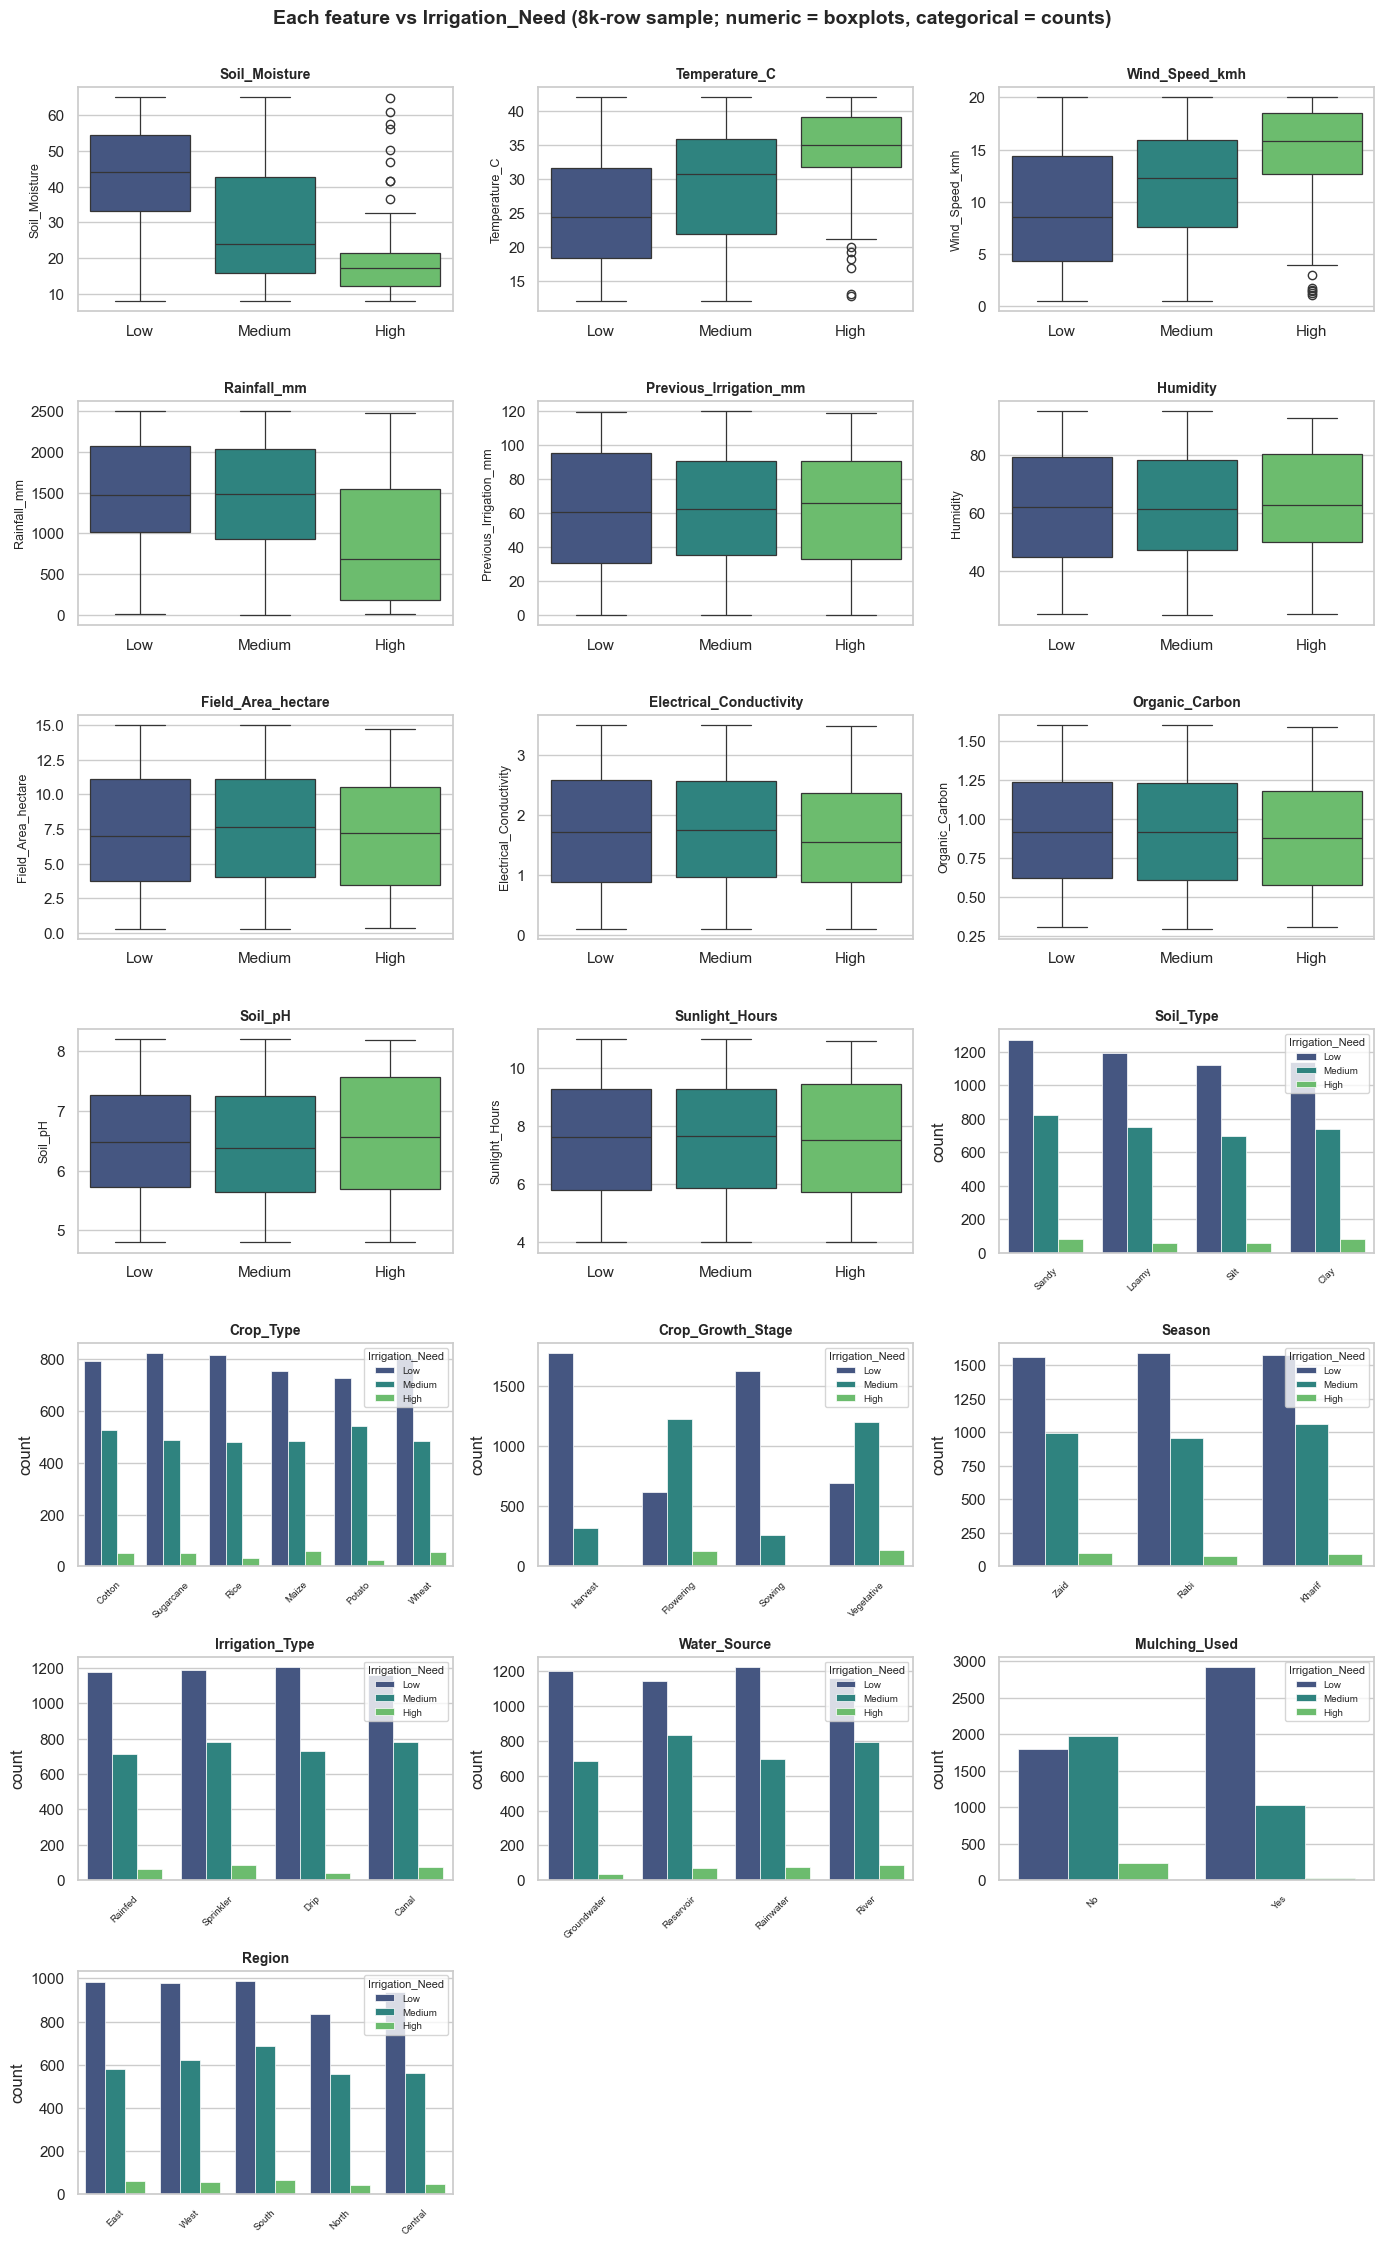

In [5]:
# One subplot per feature vs Irrigation_Need (run cell above first for numerical / categorical / feature_cols)
sns.set_theme(style="whitegrid", context="notebook")
_df = irrigations_train.copy()
preferred = ["Low", "Medium", "High"]
order = [c for c in preferred if c in set(_df["Irrigation_Need"])]
plot_sample = _df.sample(n=min(8000, len(_df)), random_state=42)

# Numerical columns (names must match CSV column headers)
numerical = [
    "Soil_Moisture",
    "Temperature_C",
    "Wind_Speed_kmh",
    "Rainfall_mm",
    "Previous_Irrigation_mm",
    "Humidity",
    "Field_Area_hectare",
    "Electrical_Conductivity",
    "Organic_Carbon",
    "Soil_pH",
    "Sunlight_Hours"
]

# Categorical columns (also pass as cat_features to CatBoost)
feature_cols = [
    "Soil_Type",
    "Crop_Type",
    "Crop_Growth_Stage",
    "Season",
    "Irrigation_Type",
    "Water_Source",
    "Mulching_Used",
    "Region",
]

all_features = numerical + feature_cols

n = len(all_features)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for ax, col in zip(axes, all_features):
    if col in numerical:
        sns.boxplot(
            data=plot_sample,
            x="Irrigation_Need",
            y=col,
            order=order,
            hue="Irrigation_Need",
            hue_order=order,
            palette="viridis",
            legend=False,
            ax=ax,
            linewidth=0.9,
        )
        ax.set_ylabel(col, fontsize=9)
    else:
        sns.countplot(
            data=plot_sample,
            x=col,
            hue="Irrigation_Need",
            hue_order=order,
            palette="viridis",
            ax=ax,
            edgecolor="white",
            linewidth=0.5,
        )
        ax.tick_params(axis="x", rotation=45, labelsize=7)
        ax.legend(title="Irrigation_Need", fontsize=7, title_fontsize=8, loc="upper right")
    ax.set_title(col, fontsize=10, fontweight="semibold")
    ax.set_xlabel("")

for j in range(len(all_features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Each feature vs Irrigation_Need (8k-row sample; numeric = boxplots, categorical = counts)",
    fontsize=14,
    fontweight="semibold",
    y=1.002,
)
plt.tight_layout()
plt.show()

## Interaction features

Engineered interactions (see table in project notes):

- **Numerical × numerical**: products (e.g. temperature × humidity, rainfall × soil moisture).
- **Categorical × categorical**: concatenated labels (e.g. soil × crop, stage × season).
- **Categorical × numerical**: one-hot encoding of the category multiplied by the numeric column (columns aligned to **train** categories so train/test match).

In [6]:
irrigations_train['Previous_Irrigation_mm'].head()

0    112.16
1     47.16
2    110.38
3     53.85
4     93.19
Name: Previous_Irrigation_mm, dtype: float64

In [7]:
def add_interaction_features(train_df, test_df):
    """Add numerical×numerical, categorical×categorical, and categorical×numerical columns."""
    train = train_df.copy()
    test = test_df.copy()

    # Numerical × Numerical (products)
    nn_pairs = [
        # temperatur of the air directly correlates with humidity
        ("Temp_x_Humidity", "Temperature_C", "Humidity"),
        # rainfall directly correlates with soil moisture
        ("Rain_x_Soil_Moisture", "Rainfall_mm", "Soil_Moisture"),
        # if previous irrigation is high, soil moisture is high
        ("PrevIrr_x_Soil_Moisture", "Previous_Irrigation_mm", "Soil_Moisture"),
        # high sunlight intensity directly correlates with temperature
        ("Sunlight_x_Temp", "Sunlight_Hours", "Temperature_C"),
        # high electrical conductivity directly correlates with soil pH
        ("EC_x_pH", "Electrical_Conductivity", "Soil_pH"),
    ]

    # create new columns for each interaction pair 
    for new_col, a, b in nn_pairs:
        train[new_col] = train[a] * train[b]
        test[new_col] = test[a] * test[b]

    # Net water balance feature
    # Evapotranspiration: how much water is loss to the air and soil via evporation
    # Formula: Temp*sunlightHours*(1(-Humidityy)/100)
    if "Evapotranspiration_estimate" not in train.columns:
        train["Evapotranspiration_estimate"] = (
            train["Temperature_C"] * train["Sunlight_Hours"] * (1 - train["Humidity"] / 100.0)
        )
    if "Evapotranspiration_estimate" not in test.columns:
        test["Evapotranspiration_estimate"] = (
            test["Temperature_C"] * test["Sunlight_Hours"] * (1 - test["Humidity"] / 100.0)
        )

    # Formula: previousIrrigation water + Rainfall water - Evaporated water through the air and soil 
    train["net_water"] = (
        train["Previous_Irrigation_mm"] + train["Rainfall_mm"] - train["Evapotranspiration_estimate"]
    )
    test["net_water"] = (
        test["Previous_Irrigation_mm"] + test["Rainfall_mm"] - test["Evapotranspiration_estimate"]
    )

    meta = {
        "numerical_interactions": [p[0] for p in nn_pairs] +
        ["Evapotranspiration_estimate", "net_water"],
    }
    return train, test, meta


irrigations_train, irrigations_test, INTERACTION_META = add_interaction_features(
    irrigations_train, irrigations_test
)
print(irrigations_train.columns)

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need',
       'Temp_x_Humidity', 'Rain_x_Soil_Moisture', 'PrevIrr_x_Soil_Moisture',
       'Sunlight_x_Temp', 'EC_x_pH', 'Evapotranspiration_estimate',
       'net_water'],
      dtype='object')


## Inspecting Skewness 

In [8]:
skew_vals = irrigations_train[numerical].apply(pd.Series.skew).sort_values().iloc[::-1]
print(skew_vals)

Organic_Carbon             0.105044
Soil_pH                    0.069547
Field_Area_hectare         0.052216
Electrical_Conductivity    0.048054
Temperature_C             -0.003627
Previous_Irrigation_mm    -0.017108
Wind_Speed_kmh            -0.027756
Sunlight_Hours            -0.034897
Soil_Moisture             -0.063614
Humidity                  -0.088835
Rainfall_mm               -0.117579
dtype: float64


In [9]:
irrigations_train["Irrigation_Need"].value_counts(normalize=True)

Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64

## Observations
- Target imbalance (Irrigation_Need) - High ≈ 3.3% vs Low ≈ 58.7% and Medium ≈ 37.9%; accuracy can look good while the model almost never predicts High, so precision/recall/F1 (especially for High) and macro/weighted summaries matter more than accuracy alone.

- Numeric skew - Largest positive skew: Organic_Carbon; largest negative skew: Rainfall_mm (with Humidity, Soil_Moisture, Sunlight_Hours also notably left-skewed); tree-based models often cope better than linear models, but linear / distance-based methods may benefit from transforms or robust scaling unless you verify they’re unnecessary on validation.

# Catboost Model Training

In [10]:
class MulticlassBalancedAccuracy:
    """Custom CatBoost eval metric: balanced accuracy for multiclass (avg recall per class)."""

    def get_final_error(self, error, weight):
        return error

    def is_max_optimal(self):
        return True

    def evaluate(self, approxes, target, weight):
        # approxes: list of per-class log-probabilities, shape (n_classes, n_samples)
        preds = np.argmax(approxes, axis=0)
        target = np.array(target, dtype=int)

        classes = np.unique(target)
        recalls = []
        for cls in classes:
            mask = target == cls
            if mask.sum() == 0:
                continue
            recalls.append((preds[mask] == cls).mean())

        score = float(np.mean(recalls))
        return score, 1.0

In [11]:
# splitting the models between the features and the target
X = irrigations_train.drop(columns=["id", "Irrigation_Need"])
y = irrigations_train["Irrigation_Need"]

# split the training dataset with a 80-20 train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# set parameters for model
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric=MulticlassBalancedAccuracy(),
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    class_weights=[1.0, 1.0, 5.0],
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200,
)


In [ ]:
# train the cat model
model.fit(
    X_train,
    y_train,
    cat_features=feature_cols,
    eval_set=(X_val, y_val),
    use_best_model=True,
)

# perform evaluation
y_pred = model.predict(X_val)

score = balanced_accuracy_score(y_val, y_pred)
print("Balanced Accuracy:", score)

print(classification_report(y_val, y_pred))
model.get_feature_importance(prettified=True)

c:\Users\EthanYongYuHeng\Desktop\irrigation-prediction\.venv\Lib\site-packages\catboost\core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.9052385	test: 0.9084333	best: 0.9084333 (0)	total: 952ms	remaining: 31m 43s
200:	learn: 0.9400289	test: 0.9411810	best: 0.9412579 (199)	total: 3m 9s	remaining: 28m 16s
400:	learn: 0.9448062	test: 0.9468167	best: 0.9468960 (399)	total: 6m 29s	remaining: 25m 51s
600:	learn: 0.9466260	test: 0.9489397	best: 0.9489397 (600)	total: 8m 53s	remaining: 20m 42s
800:	learn: 0.9482569	test: 0.9500836	best: 0.9500836 (799)	total: 11m 36s	remaining: 17m 24s
1000:	learn: 0.9493304	test: 0.9509751	best: 0.9511547 (956)	total: 13m 58s	remaining: 13m 58s
1200:	learn: 0.9501737	test: 0.9512071	best: 0.9512680 (1134)	total: 18m 7s	remaining: 12m 3s
1400:	learn: 0.9505414	test: 0.9512010	best: 0.9513802 (1270)	total: 21m 12s	remaining: 9m 4s
1600:	learn: 0.9509106	test: 0.9514872	best: 0.9516499 (1493)	total: 23m 35s	remaining: 5m 52s
1800:	learn: 0.9513768	test: 0.9520585	best: 0.9521263 (1778)	total: 26m 3s	remaining: 2m 52s
1999:	learn: 0.9519434	test: 0.9525783	best: 0.9525918 (1990)	total:

,Feature Id,Importances
0,Crop_Growth_Stage,26.392057
1,Soil_Moisture,23.509816
2,Mulching_Used,10.698605
3,Wind_Speed_kmh,10.389789
4,Temperature_C,10.185320
5,Rainfall_mm,2.872570
6,Humidity,2.309989
7,Previous_Irrigation_mm,1.838776
8,Rain_x_Soil_Moisture,1.834648
9,net_water,1.429252


## Observations 

- Validation balanced accuracy — ~0.95+ on a large holdout (126k rows) matches the custom metric trajectory and is a solid signal for multiclass balance, not raw accuracy alone.

- rain vs validation gap — Final learn ≈ 0.952 vs test ≈ 0.953 with best iteration near the end suggests little overfitting on this split; the model is not memorizing the training fold.

- Rare class (High) — Recall 0.89 with precision 0.98 means most High cases are found with few false alarms; remaining errors are mostly missed High (false negatives), which matters if irrigation alerts must catch every stress event.

- Majority classes — Low and Medium show very high precision/recall, consistent with class frequency but still indicating stable separation, not only majority-class collapse.

### Kaggle Submission
- Ranked #1264
- Acheived 94.711% Accuracy

In [15]:
X_test = irrigations_test.drop(columns=["id"])

test_preds = model.predict(X_test).ravel()

submission = pd.DataFrame({
    "id": irrigations_test["id"],
    "Irrigation_Need": test_preds,
})

# submission.to_csv("submission.csv", index=False)

CatBoostError: There is no trained model to use predict(). Use fit() to train model. Then use this method.

### Optuna + stratified K-fold (OOF)

Each trial runs 5-fold CV on the full training set and returns the mean balanced accuracy across folds.


Optional: rebuild `model` with Optuna’s `depth` and `learning_rate` (run after `study.optimize`, and after the cell that defines `X`, `y`, and the train/val split).


In [12]:
def objective(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "iterations": 1000,
        "loss_function": "MultiClass",
        "verbose": 0,
        "random_seed": 42,
        "class_weights": [1.0, 1.0, 5.0],
    }
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(**params, cat_features=feature_cols)
        model.fit(X_train_fold, 
                y_train_fold,
                eval_set=(X_val_fold,y_val_fold),
                early_stopping_rounds=50,
                verbose=100
                )
        preds = model.predict(X_val_fold)
        score = balanced_accuracy_score(y_val_fold, preds)
        scores.append(score)

    return np.mean(scores)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)
best_params = study.best_params
print("best_params:", best_params)
print("best_value (mean balanced accuracy across folds):", study.best_value)

[I 2026-04-12 11:15:26,962] A new study created in memory with name: no-name-d44f70e1-ea25-44ce-8ede-a6e828baee8d


0:	learn: 0.7840618	test: 0.7838250	best: 0.7838250 (0)	total: 1.49s	remaining: 24m 46s
100:	learn: 0.0571514	test: 0.0595389	best: 0.0595389 (100)	total: 1m 50s	remaining: 16m 24s
200:	learn: 0.0516774	test: 0.0579703	best: 0.0579678 (198)	total: 3m 45s	remaining: 14m 54s
300:	learn: 0.0475929	test: 0.0577681	best: 0.0577650 (299)	total: 5m 44s	remaining: 13m 19s
400:	learn: 0.0442754	test: 0.0577246	best: 0.0576715 (369)	total: 7m 41s	remaining: 11m 29s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05767145496
bestIteration = 369

Shrink model to first 370 iterations.
0:	learn: 0.7841532	test: 0.7842639	best: 0.7842639 (0)	total: 1.17s	remaining: 19m 29s
100:	learn: 0.0558475	test: 0.0607060	best: 0.0607060 (100)	total: 1m 56s	remaining: 17m 14s
200:	learn: 0.0506717	test: 0.0596910	best: 0.0596910 (200)	total: 3m 56s	remaining: 15m 39s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.05943881729
bestIteration = 240

Shrink model to first 241 

[I 2026-04-12 11:52:18,428] Trial 0 finished with value: 0.94992350518177 and parameters: {'depth': 9, 'learning_rate': 0.1875123738555608}. Best is trial 0 with value: 0.94992350518177.


0:	learn: 1.0046441	test: 1.0045627	best: 1.0045627 (0)	total: 746ms	remaining: 12m 25s
100:	learn: 0.0675159	test: 0.0667921	best: 0.0667921 (100)	total: 1m 12s	remaining: 10m 45s
200:	learn: 0.0626836	test: 0.0621681	best: 0.0621681 (200)	total: 2m 15s	remaining: 8m 58s
300:	learn: 0.0610762	test: 0.0608112	best: 0.0608112 (300)	total: 3m 19s	remaining: 7m 42s
400:	learn: 0.0597022	test: 0.0598478	best: 0.0598478 (400)	total: 4m 26s	remaining: 6m 38s
500:	learn: 0.0587672	test: 0.0592867	best: 0.0592867 (500)	total: 5m 33s	remaining: 5m 32s
600:	learn: 0.0580527	test: 0.0588937	best: 0.0588937 (600)	total: 6m 40s	remaining: 4m 25s
700:	learn: 0.0572858	test: 0.0585209	best: 0.0585209 (700)	total: 7m 47s	remaining: 3m 19s
800:	learn: 0.0566830	test: 0.0582665	best: 0.0582665 (800)	total: 8m 54s	remaining: 2m 12s
900:	learn: 0.0561610	test: 0.0580929	best: 0.0580861 (898)	total: 10m	remaining: 1m 6s
999:	learn: 0.0556320	test: 0.0578924	best: 0.0578924 (999)	total: 11m 6s	remaining: 0u

[I 2026-04-12 12:47:55,202] Trial 1 finished with value: 0.9483900738303381 and parameters: {'depth': 6, 'learning_rate': 0.05180079428971274}. Best is trial 0 with value: 0.94992350518177.


...

0:	learn: 1.0078325	test: 1.0077851	best: 1.0077851 (0)	total: 508ms	remaining: 8m 27s
100:	learn: 0.0812673	test: 0.0805390	best: 0.0805390 (100)	total: 44.7s	remaining: 6m 37s
200:	learn: 0.0651788	test: 0.0643900	best: 0.0643900 (200)	total: 1m 29s	remaining: 5m 54s
300:	learn: 0.0627329	test: 0.0620251	best: 0.0620251 (300)	total: 2m 12s	remaining: 5m 6s
400:	learn: 0.0615526	test: 0.0609622	best: 0.0609622 (400)	total: 2m 55s	remaining: 4m 22s
500:	learn: 0.0606706	test: 0.0602438	best: 0.0602438 (500)	total: 3m 38s	remaining: 3m 38s
600:	learn: 0.0599970	test: 0.0597704	best: 0.0597704 (600)	total: 4m 22s	remaining: 2m 54s
700:	learn: 0.0594349	test: 0.0593568	best: 0.0593568 (700)	total: 5m 5s	remaining: 2m 10s
800:	learn: 0.0589731	test: 0.0590620	best: 0.0590620 (800)	total: 5m 48s	remaining: 1m 26s
900:	learn: 0.0585822	test: 0.0588370	best: 0.0588370 (899)	total: 6m 31s	remaining: 43s
999:	learn: 0.0581990	test: 0.0586229	best: 0.0586229 (998)	total: 7m 13s	remaining: 0us

b

[I 2026-04-12 14:31:08,110] Trial 3 finished with value: 0.9476118623318668 and parameters: {'depth': 4, 'learning_rate': 0.05569945709522852}. Best is trial 0 with value: 0.94992350518177.


0:	learn: 1.0487896	test: 1.0487630	best: 1.0487630 (0)	total: 488ms	remaining: 8m 8s
100:	learn: 0.1368469	test: 0.1361137	best: 0.1361137 (100)	total: 44.4s	remaining: 6m 34s
200:	learn: 0.0785132	test: 0.0777615	best: 0.0777615 (200)	total: 1m 28s	remaining: 5m 51s
300:	learn: 0.0679840	test: 0.0671938	best: 0.0671938 (300)	total: 2m 12s	remaining: 5m 7s
400:	learn: 0.0648614	test: 0.0640760	best: 0.0640760 (400)	total: 2m 56s	remaining: 4m 23s
500:	learn: 0.0633292	test: 0.0625456	best: 0.0625456 (500)	total: 3m 40s	remaining: 3m 39s
600:	learn: 0.0623588	test: 0.0616498	best: 0.0616498 (600)	total: 4m 24s	remaining: 2m 55s
700:	learn: 0.0616867	test: 0.0610660	best: 0.0610660 (700)	total: 5m 7s	remaining: 2m 11s
800:	learn: 0.0611820	test: 0.0606464	best: 0.0606462 (799)	total: 5m 50s	remaining: 1m 27s
900:	learn: 0.0607020	test: 0.0602737	best: 0.0602737 (900)	total: 6m 33s	remaining: 43.2s
999:	learn: 0.0603030	test: 0.0599575	best: 0.0599575 (999)	total: 7m 15s	remaining: 0us



[I 2026-04-12 15:07:45,512] Trial 4 finished with value: 0.9461349666873472 and parameters: {'depth': 4, 'learning_rate': 0.030163580586637657}. Best is trial 0 with value: 0.94992350518177.


best_params: {'depth': 9, 'learning_rate': 0.1875123738555608}
best_value (mean balanced accuracy across folds): 0.94992350518177


In [ ]:
model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric=MulticlassBalancedAccuracy(),
    iterations=2000,
    learning_rate=best_params["learning_rate"],
    depth=best_params["depth"],
    class_weights=[1.0, 1.0, 5.0],
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200,
)